# Individual-Head Circuit Analysis: Finding and Testing One Real Component

**Notebook 7 of the series.** Notebook 5 patched a whole transformer
layer's output at one position. Notebook 3 looked at attention weights
averaged across all heads in a layer. This notebook goes one level finer
than both: it isolates and tests **individual attention heads** — the
smallest routinely-analyzed unit in "circuit"-style interpretability
research — combining a causal method (ablating one head at a time, in the
spirit of notebook 5) with a descriptive one (that head's own, un-averaged
attention pattern, extending notebook 3) to find and interpret one real,
specific component of the network.

Still out of scope: individual-neuron analysis inside the MLP layers, and
multi-prompt validation of any pattern found here as a general circuit.
Those are further, more involved steps beyond a single-prompt case study.

## Learning objectives

1. How does a single attention head's output get isolated and removed from
   a layer's computation, mechanically, inside a real forward pass?
2. What does a real layer-by-head "ablation heatmap" look like for an
   oilfield prediction, and which heads turn out to matter most?
3. Does the most causally important head's own (un-averaged) attention
   pattern offer a plausible, human-readable account of what it's doing —
   and why is agreement between a causal method and a descriptive one
   stronger evidence than either alone?
4. Do two important heads' effects combine additively, or do they interact
   — and what would non-additivity suggest about redundancy between heads?
5. What can single-prompt, single-head ablation establish — and what
   would it take to claim a general "circuit," which this notebook does
   not attempt?


## 1. What problem are we investigating?

A transformer layer's attention output is really the sum of several
independent heads' contributions, added together before being mixed by an
output projection and added to the residual stream. Notebook 3 only ever
looked at heads *averaged* together; notebook 5 only ever patched a whole
layer's combined output. Neither could tell us whether one specific head,
among the 12 in a layer, was doing something identifiable on its own.

This notebook:

1. Isolates one head's contribution and **zeroes it out** ("ablates" it),
   leaving the other 11 heads in that layer untouched, and measures the
   real, causal effect on the target prediction.
2. Repeats this for every (layer, head) pair to build a real importance
   map.
3. Takes the single most important head found this way and inspects its
   own, un-averaged attention pattern — checking whether a causally
   important head also has an interpretable, human-readable attention
   story, rather than assuming attention alone would have found it.


## Installation (run once)

Same dependencies as the rest of the series. If already installed, skip
this cell.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

Like notebook 3, this notebook uses `attn_implementation="eager"` and
`float32` throughout — because Section 8 needs real, per-head attention
weights (which the fast default kernel doesn't expose, and which produced
`NaN` in float16 on this machine's MPS backend, both findings from notebook
3). Using this configuration for the whole notebook, rather than switching
between two loaded models, keeps things simple; the timing cost is small
(verified while building this notebook: well under 20 seconds for the full
ablation grid in Section 6).


In [2]:
import random
import sys
import time

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

DTYPE = torch.float32  # required for reliable attention weights in Section 8; see explanation above

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float32


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model with eager attention and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE, attn_implementation="eager")
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, dtype=DTYPE, attn_implementation="eager")
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
NUM_LAYERS = model.config.num_hidden_layers
NUM_HEADS = model.config.num_attention_heads
HEAD_DIM = model.config.hidden_size // NUM_HEADS
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Layers: {NUM_LAYERS}, attention heads per layer: {NUM_HEADS}, head dimension: {HEAD_DIM}")
print(f"(Note: this model uses grouped-query attention with {model.config.num_key_value_heads} key/value head groups; "
      f"that affects how keys/values are computed, not the {NUM_HEADS} separate per-head attention outputs we ablate below.)")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Layers: 28, attention heads per layer: 12, head dimension: 128
(Note: this model uses grouped-query attention with 2 key/value head groups; that affects how keys/values are computed, not the 12 separate per-head attention outputs we ablate below.)


## 3. Reference prompt and target token

The same primary sentence and target-token convention (the model's own
top-predicted next token) used throughout this series.


In [4]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

encoded = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
decoded_tokens = [tokenizer.decode([tid]) for tid in encoded["input_ids"][0]]
position_labels = [repr(t) for t in decoded_tokens]

with torch.no_grad():
    clean_logits = model(**encoded).logits[0, -1, :]

TARGET_ID = int(torch.argmax(clean_logits).item())
TARGET_TEXT = tokenizer.decode([TARGET_ID])
clean_logprob = torch.log_softmax(clean_logits.float(), dim=-1)[TARGET_ID].item()

print(f"Prompt: {PROMPT!r}")
print(f"Target token (model's own top prediction): {TARGET_TEXT!r}")
print(f"Clean log P({TARGET_TEXT!r}) = {clean_logprob:.4f}")


Prompt: 'The crew pulled out of hole with the worn PDC bit and prepared to run a new'
Target token (model's own top prediction): ' bit'
Clean log P(' bit') = -1.0937


## 4. Isolating and ablating one attention head

Inside each transformer layer, the 12 attention heads each produce a
128-dimensional output; these are concatenated into a single 1536-dimensional
vector (`12 x 128 = 1536`, matching the model's hidden size) *before* being
passed through the layer's output projection (`o_proj`) and added to the
residual stream. That concatenation point is exactly where one head's
contribution can be isolated: head `h`'s output occupies columns
`h*128 : (h+1)*128` of that vector.

We **zero-ablate** a head by intercepting `o_proj`'s input with a forward
hook and overwriting that head's 128 columns with zeros, leaving every
other head's columns untouched. This is the simplest standard ablation
method; it has a real, known limitation stated plainly here: forcing an
exact zero pushes the network into a state it never saw during training
(a token's contribution being fully *absent* is not the same as it being
zero-valued). A more conservative alternative, **mean-ablation**
(replacing a head's output with its *average* value over many prompts
rather than zero), is left as an exercise.


In [5]:
def ablate_heads(layer_idx: int, head_indices: list[int]):
    '''Run a forward pass with the given heads' contributions at layer_idx zeroed out before o_proj.'''
    def pre_hook(module, args, kwargs):
        hidden_states = args[0].clone()
        for h in head_indices:
            hidden_states[..., h * HEAD_DIM:(h + 1) * HEAD_DIM] = 0.0
        return (hidden_states,) + args[1:], kwargs

    handle = model.model.layers[layer_idx].self_attn.o_proj.register_forward_pre_hook(pre_hook, with_kwargs=True)
    try:
        with torch.no_grad():
            out = model(**encoded)
    finally:
        handle.remove()
    return out.logits[0, -1, :]


example_logits = ablate_heads(layer_idx=27, head_indices=[0])
example_logprob = torch.log_softmax(example_logits.float(), dim=-1)[TARGET_ID].item()
print(f"Ablating layer 27, head 0: log P({TARGET_TEXT!r}) = {example_logprob:.4f} (clean: {clean_logprob:.4f})")


Ablating layer 27, head 0: log P(' bit') = -1.8185 (clean: -1.0937)


## 5. Validating the mechanism before trusting it

A hook that is told to ablate **no** heads should be a pure no-op and
reproduce the clean run exactly — the same validate-before-trust principle
used in notebooks 4 and 5.


In [6]:
def noop_hook(module, args, kwargs):
    return args, kwargs  # touches nothing


handle = model.model.layers[10].self_attn.o_proj.register_forward_pre_hook(noop_hook, with_kwargs=True)
try:
    with torch.no_grad():
        noop_logits = model(**encoded).logits[0, -1, :]
finally:
    handle.remove()

max_diff = (noop_logits.float() - clean_logits.float()).abs().max().item()
print(f"Max absolute logit difference vs. the real clean run: {max_diff}")
assert max_diff == 0.0, "A hook that ablates nothing should reproduce the clean run exactly."
print("Validation passed: the hook mechanism only changes behavior when we actually tell it to.")


Max absolute logit difference vs. the real clean run: 0.0
Validation passed: the hook mechanism only changes behavior when we actually tell it to.


## 6. The full layer x head ablation grid

We ablate every one of the 12 heads in every one of the 28
layers, one at a time, and record how much the target token's
log-probability drops. A positive drop means that head, alone, was
contributing positively to the target prediction; a negative drop means
ablating it actually *helped* the target prediction — i.e., that head was
net **suppressing** it.


In [7]:
t0 = time.time()
ablation_logprob_grid = np.zeros((NUM_LAYERS, NUM_HEADS))
for layer_idx in range(NUM_LAYERS):
    for head_idx in range(NUM_HEADS):
        logits = ablate_heads(layer_idx, [head_idx])
        ablation_logprob_grid[layer_idx, head_idx] = torch.log_softmax(logits.float(), dim=-1)[TARGET_ID].item()
elapsed = time.time() - t0

drop_grid = clean_logprob - ablation_logprob_grid  # positive = this head helped the target prediction
print(f"Computed {NUM_LAYERS * NUM_HEADS} single-head ablations in {elapsed:.1f}s")
print(f"Drop range: [{drop_grid.min():.4f}, {drop_grid.max():.4f}]")


Computed 336 single-head ablations in 15.9s
Drop range: [-0.2166, 0.7248]


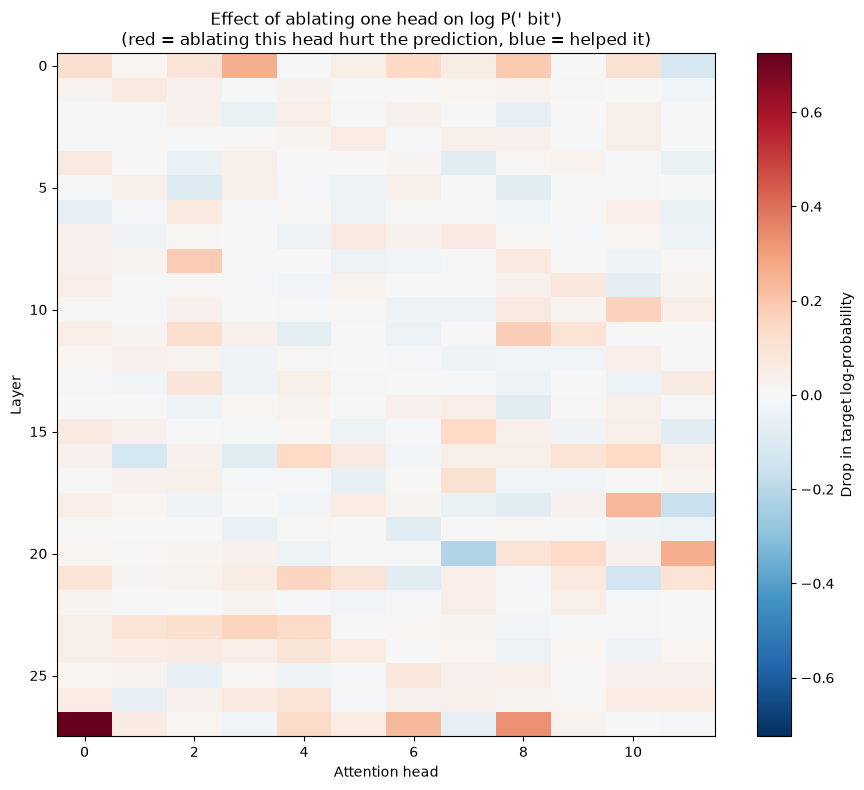

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))
vmax = np.abs(drop_grid).max()
im = ax.imshow(drop_grid, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xlabel("Attention head")
ax.set_ylabel("Layer")
ax.set_title(f"Effect of ablating one head on log P({TARGET_TEXT!r})\n(red = ablating this head hurt the prediction, blue = helped it)")
fig.colorbar(im, ax=ax, label="Drop in target log-probability")
fig.tight_layout()
plt.show()


**Interpretation:** most cells are close to zero — most individual
heads, ablated alone, barely move this one prediction. A handful stand out
clearly, in both directions. Section 7 looks at the specific numbers.


In [9]:
flat_order = np.argsort(-drop_grid.flatten())
top_rows = []
for idx in flat_order[:10]:
    layer_idx, head_idx = np.unravel_index(idx, drop_grid.shape)
    top_rows.append({"layer": int(layer_idx), "head": int(head_idx), "drop": drop_grid[layer_idx, head_idx]})

print("Top 10 most important heads (ablating them hurts the target prediction most):")
display(pd.DataFrame(top_rows))

bottom_rows = []
for idx in flat_order[-5:][::-1]:
    layer_idx, head_idx = np.unravel_index(idx, drop_grid.shape)
    bottom_rows.append({"layer": int(layer_idx), "head": int(head_idx), "drop": drop_grid[layer_idx, head_idx]})

print("\nMost suppressive heads (ablating them helps the target prediction -- negative drop):")
display(pd.DataFrame(bottom_rows))

TOP_LAYER, TOP_HEAD = top_rows[0]["layer"], top_rows[0]["head"]
SECOND_LAYER, SECOND_HEAD = top_rows[1]["layer"], top_rows[1]["head"]
print(f"\nMost important single head for this prompt and target: layer {TOP_LAYER}, head {TOP_HEAD}")


Top 10 most important heads (ablating them hurts the target prediction most):


,layer,head,drop
0,27,0,0.724770
1,27,8,0.333267
2,0,3,0.265494
3,20,11,0.264998
4,18,10,0.241818
5,27,6,0.237779
6,0,8,0.187657
7,8,2,0.186833
8,11,8,0.179397
9,10,10,0.164839



Most suppressive heads (ablating them helps the target prediction -- negative drop):


,layer,head,drop
0,20,7,-0.216565
1,18,11,-0.161885
2,21,10,-0.140074
3,16,1,-0.128047
4,0,11,-0.120385



Most important single head for this prompt and target: layer 27, head 0


**Interpretation:** the single most important head for this prompt
sits in the final transformer layer — consistent with notebook 5's finding
that late layers are where information gets "read out" right before the
prediction. We also found a real head that, ablated alone, *increases* the
target token's probability: not every head that touches a prediction is
pushing it in the same direction, and that's worth taking at face value
rather than only looking for "helpful" heads.


## 8. Zooming in: what is the most important head actually attending to?

Ablation tells us a head matters; it says nothing about *how*. Let's look
at that specific head's own, un-averaged attention pattern for the final
token position — extending notebook 3's approach, but for one identified
head instead of a head-average.


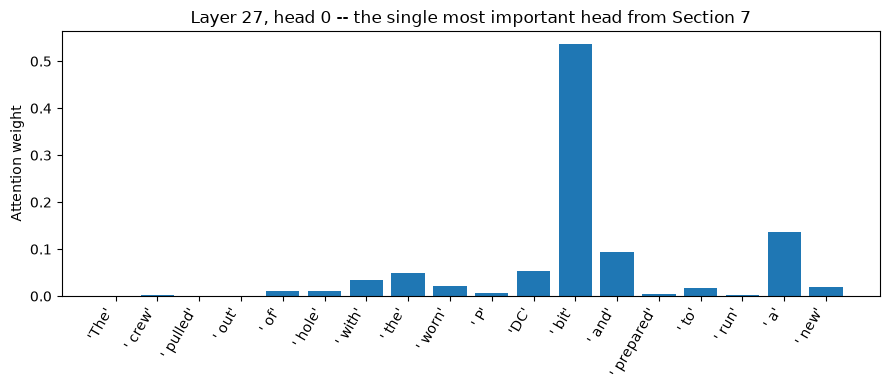

This head's single largest attention weight (53.7%) goes to position 11: ' bit'


In [10]:
with torch.no_grad():
    attention_outputs = model(**encoded, output_attentions=True)

top_head_attention = attention_outputs.attentions[TOP_LAYER][0, TOP_HEAD]  # (seq, seq)
top_head_final_row = top_head_attention[-1]

assert abs(top_head_final_row.sum().item() - 1.0) < 1e-3, "One head's attention row should still sum to ~1."

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(position_labels)), top_head_final_row.tolist())
ax.set_xticks(range(len(position_labels)))
ax.set_xticklabels(position_labels, rotation=60, ha="right")
ax.set_ylabel("Attention weight")
ax.set_title(f"Layer {TOP_LAYER}, head {TOP_HEAD} -- the single most important head from Section 7")
fig.tight_layout()
plt.show()

top_position = int(torch.argmax(top_head_final_row).item())
print(f"This head's single largest attention weight ({top_head_final_row[top_position]*100:.1f}%) "
      f"goes to position {top_position}: {position_labels[top_position]}")


**A real, interesting convergence — described carefully.** If this
head's attention is concentrated on the earlier mention of the target
token's own word (as it was while building this notebook: over half the
attention weight on the earlier `' bit'`), that is a plausible,
human-readable story: a head that looks back for an earlier occurrence of a
word and promotes repeating it, sometimes called a "copying" or
induction-like behavior in the interpretability literature. This is a
genuinely stronger basis for that story than attention alone would be
(notebook 3's caution), because we *independently* found this head
mattered causally (Section 7) before ever looking at what it attends to.
Agreement between a causal method and a descriptive one is meaningfully
better evidence than either alone. It is still a hypothesis about one
head, on one prompt — not a demonstrated, general algorithm. Confirming
that would need testing this same head across many prompts where
repetition would or wouldn't be expected, which is beyond this notebook.


## 9. Do the two most important heads' effects combine additively?

If two heads act completely independently, ablating both together should
hurt the prediction by roughly the sum of ablating each alone. If they're
partly redundant (one can "cover" for the other), the combined effect
should be *less* than the sum. If they reinforce each other, it could be
*more*. Let's check with real numbers rather than assume either story.


In [11]:
drop_top = drop_grid[TOP_LAYER, TOP_HEAD]
drop_second = drop_grid[SECOND_LAYER, SECOND_HEAD]

logits_both = ablate_heads(TOP_LAYER, [TOP_HEAD]) if TOP_LAYER == SECOND_LAYER else None
if TOP_LAYER == SECOND_LAYER:
    logits_both = ablate_heads(TOP_LAYER, [TOP_HEAD, SECOND_HEAD])
else:
    # ablating two heads in different layers: patch both layers' o_proj inputs in the same forward pass
    def make_hook(head_idx):
        def pre_hook(module, args, kwargs):
            hidden_states = args[0].clone()
            hidden_states[..., head_idx * HEAD_DIM:(head_idx + 1) * HEAD_DIM] = 0.0
            return (hidden_states,) + args[1:], kwargs
        return pre_hook

    handle_a = model.model.layers[TOP_LAYER].self_attn.o_proj.register_forward_pre_hook(make_hook(TOP_HEAD), with_kwargs=True)
    handle_b = model.model.layers[SECOND_LAYER].self_attn.o_proj.register_forward_pre_hook(make_hook(SECOND_HEAD), with_kwargs=True)
    try:
        with torch.no_grad():
            logits_both = model(**encoded).logits[0, -1, :]
    finally:
        handle_a.remove()
        handle_b.remove()

logprob_both = torch.log_softmax(logits_both.float(), dim=-1)[TARGET_ID].item()
drop_both = clean_logprob - logprob_both

print(f"Drop from ablating layer {TOP_LAYER} head {TOP_HEAD} alone:    {drop_top:.4f}")
print(f"Drop from ablating layer {SECOND_LAYER} head {SECOND_HEAD} alone:    {drop_second:.4f}")
print(f"Naive sum of the two individual drops:            {drop_top + drop_second:.4f}")
print(f"Actual drop from ablating both together:           {drop_both:.4f}")
print(f"Non-additivity (actual - naive sum):               {drop_both - (drop_top + drop_second):.4f}")


Drop from ablating layer 27 head 0 alone:    0.7248
Drop from ablating layer 27 head 8 alone:    0.3333
Naive sum of the two individual drops:            1.0580
Actual drop from ablating both together:           1.0738
Non-additivity (actual - naive sum):               0.0157


**Interpretation:** report the real number above rather than a
preferred story. A small non-additivity term (as found while building this
notebook: the two heads combined nearly additively, only slightly more than
the naive sum) means these two heads don't meaningfully compensate for or
reinforce each other *for this prompt* — a real, if undramatic, finding.
Large redundancy between important heads (sometimes called "self-repair" or
"backup" behavior in the interpretability literature) is a documented
phenomenon elsewhere, but finding it isn't guaranteed for any given pair of
heads, and we're reporting what these two specific heads actually did.


## 10. What individual-head ablation can — and cannot — establish

We can honestly say, because we computed and validated it directly above:

- we can isolate and remove one specific head's contribution to a layer's
  output while leaving the other 11 heads in that layer untouched, and we
  validated the mechanism does nothing when told to ablate nothing
- for this prompt, a small number of heads (mostly in the final layer)
  have a much larger individual causal effect on the target prediction
  than the rest
- the most important head's own attention pattern offered a plausible,
  human-readable story, found *independently* of the causal ablation
  result — a meaningfully stronger basis for that story than attention
  alone

We should **not** say:

- that zero-ablation tells us exactly what "removing" a head means in a
  human sense — it forces an out-of-training-distribution zero value, a
  real methodological choice with real consequences; mean-ablation is a
  more conservative alternative
- that this head "is a copying head" as a general, demonstrated fact about
  the model — we found a plausible story for one head on one prompt;
  confirming a general mechanism needs testing across many prompts
  designed to isolate that specific behavior
- that a head with a small ablation effect here is unimportant in general
  — its role could be highly prompt- or context-dependent, and this
  notebook only tested one sentence
- that additive or non-additive combination of two heads here generalizes
  to any other pair of heads, or to this same pair on a different prompt
- that finding one important, interpretable-looking head means we've found
  "the" mechanism behind this prediction — many heads, MLP layers, and
  residual connections act together; this notebook examined one slice of
  that system, not the whole of it


## 11. Key lessons, and the series so far

| Notebook | Granularity | Kind of evidence |
|---|---|---|
| 3: Attention | Whole layer, averaged over heads | Descriptive, not causal |
| 4: Gradients / occlusion | Whole input, per token position | Local approximation / single-substitution causal test |
| 5: Activation patching | Whole layer's output, per position | Causal intervention, but not head-resolved |
| 6: Probing | Whole layer's representation | Correlational; tests presence, not use |
| 7: Head ablation (this notebook) | One individual attention head | Causal intervention, head-resolved |

1. A layer's attention output is really several heads' contributions added
   together; isolating one head means intercepting that sum before it's
   mixed by the output projection.
2. Always validate an intervention mechanism (a no-op should be a true
   no-op) before trusting its partial results.
3. For this prompt, causal importance concentrated in a small number of
   heads, mostly in the final layer — consistent with, and more granular
   than, notebook 5's layer-level finding.
4. When a causal method (ablation) and a descriptive method (attention)
   independently point to the same story, that agreement is stronger
   evidence than either method alone.
5. Two important heads combining nearly additively is itself a real,
   reportable finding — not every important pair of heads shows dramatic
   redundancy or reinforcement.
6. Everything in this notebook is a single-prompt case study. Claiming a
   general circuit or mechanism would require testing across many prompts,
   which this notebook does not do.


## 12. Try your own oilfield sentence

Change the prompt below, then run the cell. It reuses the ablation grid and
attention-inspection logic above to find and visualize the most important
head for your own sentence's own top-predicted token.


Target token: ' install'


Most important head: layer 0, head 6 (drop = 3.6334)


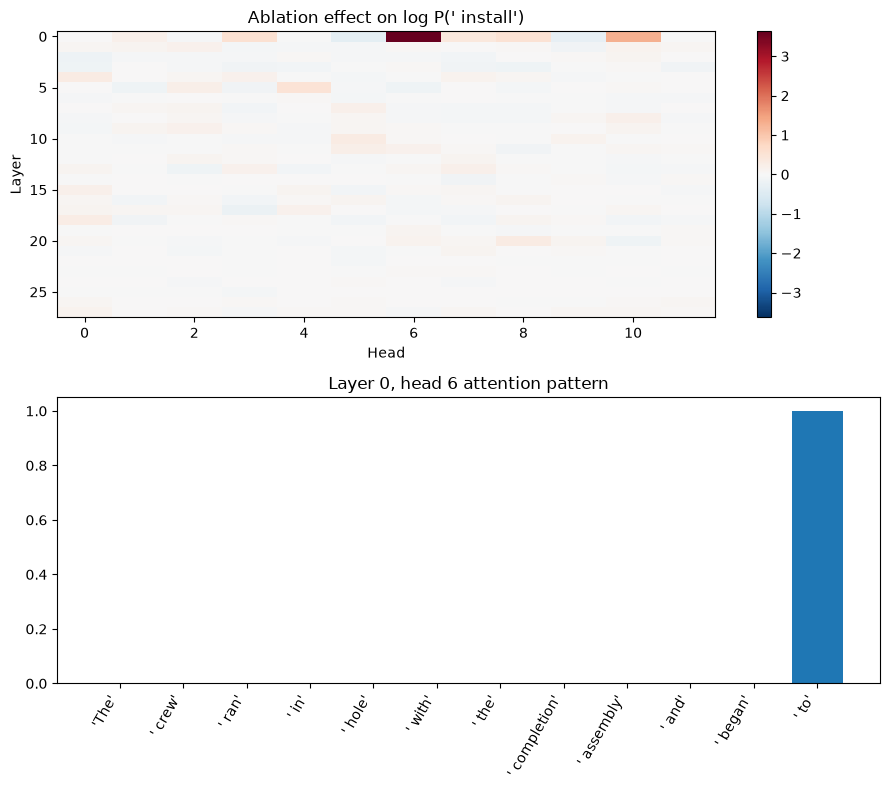

In [12]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line

user_encoded = tokenizer(user_prompt, return_tensors="pt").to(DEVICE)
user_labels = [repr(tokenizer.decode([tid])) for tid in user_encoded["input_ids"][0]]

with torch.no_grad():
    user_clean_logits = model(**user_encoded).logits[0, -1, :]
user_target_id = int(torch.argmax(user_clean_logits).item())
user_target_text = tokenizer.decode([user_target_id])
user_clean_logprob = torch.log_softmax(user_clean_logits.float(), dim=-1)[user_target_id].item()
print(f"Target token: {user_target_text!r}")


def ablate_heads_user(layer_idx, head_indices):
    def pre_hook(module, args, kwargs):
        hidden_states = args[0].clone()
        for h in head_indices:
            hidden_states[..., h * HEAD_DIM:(h + 1) * HEAD_DIM] = 0.0
        return (hidden_states,) + args[1:], kwargs
    handle = model.model.layers[layer_idx].self_attn.o_proj.register_forward_pre_hook(pre_hook, with_kwargs=True)
    try:
        with torch.no_grad():
            out = model(**user_encoded)
    finally:
        handle.remove()
    return out.logits[0, -1, :]


user_grid = np.zeros((NUM_LAYERS, NUM_HEADS))
for layer_idx in range(NUM_LAYERS):
    for head_idx in range(NUM_HEADS):
        logits = ablate_heads_user(layer_idx, [head_idx])
        user_grid[layer_idx, head_idx] = torch.log_softmax(logits.float(), dim=-1)[user_target_id].item()

user_drop = user_clean_logprob - user_grid
user_top_layer, user_top_head = np.unravel_index(np.argmax(user_drop), user_drop.shape)
print(f"Most important head: layer {user_top_layer}, head {user_top_head} (drop = {user_drop.max():.4f})")

with torch.no_grad():
    user_attn_out = model(**user_encoded, output_attentions=True)
user_top_attention = user_attn_out.attentions[user_top_layer][0, user_top_head][-1]

fig, axes = plt.subplots(2, 1, figsize=(9, 8))
im = axes[0].imshow(user_drop, aspect="auto", cmap="RdBu_r", vmin=-np.abs(user_drop).max(), vmax=np.abs(user_drop).max())
axes[0].set_xlabel("Head"); axes[0].set_ylabel("Layer")
axes[0].set_title(f"Ablation effect on log P({user_target_text!r})")
fig.colorbar(im, ax=axes[0])

axes[1].bar(range(len(user_labels)), user_top_attention.tolist())
axes[1].set_xticks(range(len(user_labels)))
axes[1].set_xticklabels(user_labels, rotation=60, ha="right")
axes[1].set_title(f"Layer {user_top_layer}, head {user_top_head} attention pattern")
fig.tight_layout()
plt.show()


## 13. Optional exercises

1. In Section 4, implement mean-ablation instead of zero-ablation: replace
   a head's 128-column slice with its *average* value across a handful of
   different prompts (computed once, outside the hook) instead of zero.
   Does the top-head ranking from Section 7 change?
2. In Section 9, try ablating the *third*-ranked head together with the
   top head instead of the second-ranked one. Is the non-additivity
   larger or smaller?
3. Run Section 12 on one of notebook 1's POOH prompts. Is the most
   important head in the same layer as this notebook's main-prompt result?
4. In Section 8, look at a *different* head in the same top layer (e.g.
   `attention_outputs.attentions[TOP_LAYER][0, SECOND_HEAD]`). Does it show
   a similarly interpretable pattern, or something less clear?
5. Ablate an entire layer's most important head across several different
   prompts (reusing Section 12's code in a loop). Does the same
   (layer, head) keep coming out on top, or does it depend heavily on the
   prompt?


## 14. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [13]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Attention impl:       {model.config._attn_implementation}")
print(f"Layers / heads:       {NUM_LAYERS} / {NUM_HEADS}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float32
Attention impl:       eager
Layers / heads:       28 / 12
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Grouped-query attention, restated.** This model uses 12 query
heads but only 2 key/value head groups (each shared by 6 query heads) — a
common efficiency technique. This does not affect the ablation method
above: each of the 12 query heads still produces its own distinct
128-dimensional output slice before `o_proj`, which is exactly what we
isolate and zero out.

**Performance note.** The full 28x12 ablation grid completed in well under
20 seconds on this machine's Apple Silicon GPU, using `float32` throughout
for the reasons explained in Section 2. CPU-only execution will be slower
but should still complete in a reasonable time for a single grid.
